We need to install **RAPIDS cuML** because


*   It is similar to sklaern
*   It provides GPU-accelerated models which we need for this huge dataset as CPU based training will take a ton of time.

Installation can take a bit of time so be patient.



In [ ]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Wed_Aug_20_01:58:59_PM_PDT_2025
Cuda compilation tools, release 13.0, V13.0.88
Build cuda_13.0.r13.0/compiler.36424714_0


In [1]:
# 1. Remove every RAPIDS / CuPy package, both cu12 and cu13
!pip list --format=freeze | grep -Ei 'cu12|cu13|cuda12|cuda13|^cuml|^cudf|^cupy|^rmm|^pylibraft|^raft' | cut -d= -f1 | xargs -r pip uninstall -y

# 2. Clean install for CUDA 13 (matches your nvcc 13.0)
!pip install -U --extra-index-url=https://pypi.nvidia.com cudf-cu13 cuml-cu13 cupy-cuda13x

Found existing installation: cucim-cu13 26.6.0
Uninstalling cucim-cu13-26.6.0:
  Successfully uninstalled cucim-cu13-26.6.0
Found existing installation: cudf-cu13 26.6.0
Uninstalling cudf-cu13-26.6.0:
  Successfully uninstalled cudf-cu13-26.6.0
Found existing installation: cudf-polars-cu13 26.6.0
Uninstalling cudf-polars-cu13-26.6.0:
  Successfully uninstalled cudf-polars-cu13-26.6.0
Found existing installation: cuml-cu13 26.6.0
Uninstalling cuml-cu13-26.6.0:
  Successfully uninstalled cuml-cu13-26.6.0
Found existing installation: cupy-cuda13x 14.0.1
Uninstalling cupy-cuda13x-14.0.1:
  Successfully uninstalled cupy-cuda13x-14.0.1
Found existing installation: cuvs-cu13 26.6.0
Uninstalling cuvs-cu13-26.6.0:
  Successfully uninstalled cuvs-cu13-26.6.0
Found existing installation: dask-cudf-cu13 26.6.0
Uninstalling dask-cudf-cu13-26.6.0:
  Successfully uninstalled dask-cudf-cu13-26.6.0
Found existing installation: distributed-ucxx-cu13 0.50.1
Uninstalling distributed-ucxx-cu13-0.50.1:
  Su

## Import Libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import time
# Cuml-based counterpart of sklearn
import cudf
from cuml.metrics import accuracy_score, roc_auc_score
from cuml.preprocessing import StandardScaler
from cuml.model_selection import train_test_split

# Precision score not available in cuml
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc,confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize


## Load the dataset


In [3]:
# You can download the dataset from this link https://drive.google.com/file/d/1dCgctWx97hi68Hvsp9MYr_UxcMBYO5PO/view?usp=drive_link
# Upload it in the files section

dataset = cudf.read_csv('creditcard_2023.csv')

In [4]:
dataset.shape

(568630, 31)

In [5]:
dataset.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [6]:
dataset.columns
# The Columns through V1 to V28 are anonymized to protect the cardholders' identities.

Index(['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

## Data Preprocessing

### Data Cleaning

In [7]:
# checking for missing values
missing_values = dataset.isnull().sum()
missing_values

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

 There are no null values here this is good news

### Feature Engineering

We don't need this step here

### Checking for Dataset Balance

In [8]:
# Let's check how much transactions are fraudlent and how much are genuine
transaction_counts = dataset['Class'].value_counts()

transaction_counts


Class
0    284315
1    284315
Name: count, dtype: int64

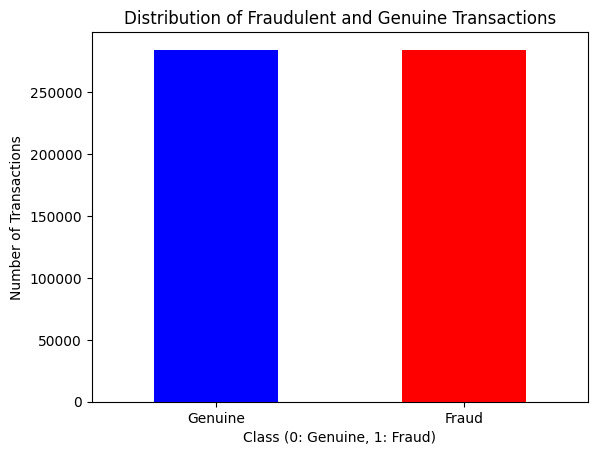

In [9]:
# Plot the distribution of the 'Class' column
dataset['Class'].value_counts().to_pandas().plot(kind='bar', color=['blue', 'red'])
plt.title('Distribution of Fraudulent and Genuine Transactions')
plt.xlabel('Class (0: Genuine, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Genuine', 'Fraud'], rotation=0)
plt.show()

It is a perfectly balanced dataset we can move further

### Feature Scaling

In [10]:
# Other values are scaled perfectly we can scale amount column for models like SVM
scaler = StandardScaler()
dataset['Amount'] = scaler.fit_transform(dataset[['Amount']])


In [11]:
dataset.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,0.858447,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,-0.796369,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,-1.377011,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,-0.962119,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,0.323285,0


### Splitting into Train and Test Datasets

In [12]:
X = dataset.drop(columns=['id','Class'])  # All columns except the target column and id column
y = dataset['Class']  # Target column
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert features to float32
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

#Conversion to int32 for compatibility
y_train = y_train.astype('int32')
y_test = y_test.astype('int32')

In [13]:
print ('X_train shape', X_train.shape)
print ('X_test shape', X_test.shape)
print ('y_train shape', y_train.shape)
print ('y_test shape', y_test.shape)


X_train shape (454904, 29)
X_test shape (113726, 29)
y_train shape (454904,)
y_test shape (113726,)


## Training Different Models


### 1. Logistic Regression

#### Training The Model

In [14]:
from cuml.linear_model import LogisticRegression
lr_model = LogisticRegression()

In [15]:
start_time = time.time()
lr_model.fit(X_train, y_train)
end_time = time.time()

training_time_lr = end_time - start_time
print(f"Training time Logistic Regressopm: {training_time_lr:.2f} seconds")

Training time Logistic Regressopm: 6.08 seconds


#### Making Predictions

In [16]:
# Predict on the test set
lr_y_pred = lr_model.predict(X_test)
type(X_test)
lr_y_pred_prob = lr_model.predict_proba(X_test.to_pandas())[1]  # Probabilities for ROC-AUC calculation

#### Evaluate the Model

#####  a.  Accuracy, Precision, Recall, and F1-Score


In [17]:
# Print evaluation metrics
lr_accuracy = accuracy_score(y_test, lr_y_pred)
lr_precision = precision_score(y_test.to_numpy(), lr_y_pred.to_numpy())
lr_recall = recall_score(y_test.to_numpy(), lr_y_pred.to_numpy())
lr_f1 = f1_score(y_test.to_numpy(), lr_y_pred.to_numpy())

print(f'Accuracy: {lr_accuracy:.4f}')
print(f'Precision: {lr_precision:.4f}')
print(f'Recall: {lr_recall:.4f}')
print(f'F1 Score: {lr_f1:.4f}')

Accuracy: 0.9650
Precision: 0.9772
Recall: 0.9522
F1 Score: 0.9645


##### b. ROC-AUC Score

In [18]:
lr_roc_auc = roc_auc_score(y_test, lr_y_pred_prob)
print(f'ROC-AUC Score: {lr_roc_auc:.4f}')

ROC-AUC Score: 0.9935


##### c. Classification Report

In [19]:
print("Classification Report:\n", classification_report(y_test.to_numpy(), lr_y_pred.to_numpy()))


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97     56863
           1       0.98      0.95      0.96     56863

    accuracy                           0.96    113726
   macro avg       0.97      0.96      0.96    113726
weighted avg       0.97      0.96      0.96    113726



##### d. Confusion Matrix

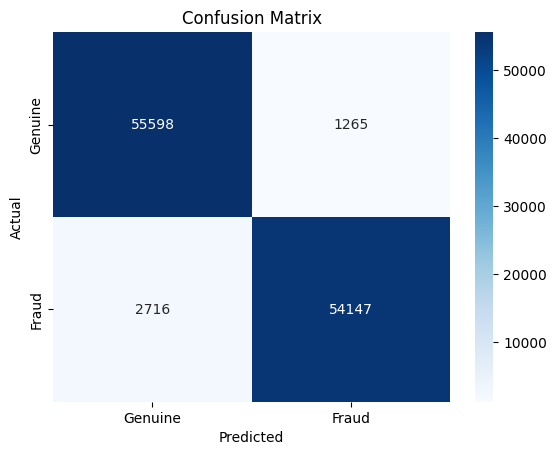

In [20]:
# Plot the confusion matrix for a better visualization
lr_cm = confusion_matrix(y_test.to_numpy(), lr_y_pred.to_numpy())
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 2. Random Forest

#### Training The Model

In [21]:
from cuml.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100)


In [22]:
start_time = time.time()

rf_model.fit(X_train, y_train)

end_time = time.time()

training_time_rf = end_time - start_time
print(f"Training time Random Forest: {training_time_rf:.2f} seconds")

Training time Random Forest: 4.38 seconds


#### Making Predictions

In [23]:
# Predict on the test set
rf_y_pred = rf_model.predict(X_test)
rf_y_pred_prob = rf_model.predict_proba(X_test.to_pandas())[1]  # Probabilities for ROC-AUC calculation

#### Evaluate the Model

#####  a.  Accuracy, Precision, Recall, and F1-Score


In [24]:
# Print evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test.to_numpy(), rf_y_pred.to_numpy())
rf_recall = recall_score(y_test.to_numpy(), rf_y_pred.to_numpy())
rf_f1 = f1_score(y_test.to_numpy(), rf_y_pred.to_numpy())

print(f'Accuracy: {rf_accuracy:.4f}')
print(f'Precision: {rf_precision:.4f}')
print(f'Recall: {rf_recall:.4f}')
print(f'F1 Score: {rf_f1:.4f}')

Accuracy: 0.9999
Precision: 0.9997
Recall: 1.0000
F1 Score: 0.9999


##### b. ROC-AUC Score

In [25]:
rf_roc_auc = roc_auc_score(y_test.to_numpy(), rf_y_pred_prob.to_numpy())
print(f'ROC-AUC Score: {rf_roc_auc:.4f}')

ROC-AUC Score: 1.0000


##### c. Classification Report

In [26]:
print("Classification Report:\n", classification_report(y_test.to_numpy(), rf_y_pred.to_numpy()))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



##### d. Confusion Matrix

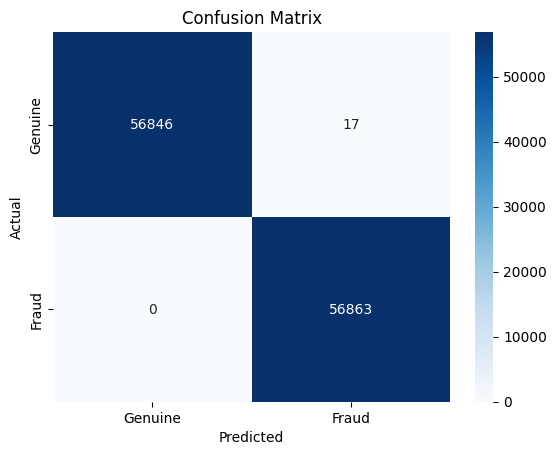

In [27]:
# Plot the confusion matrix for a better visualization
rf_cm = confusion_matrix(y_test.to_numpy(), rf_y_pred.to_numpy())
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 3. Support Vector Machine (Linear Kernel)

#### Training The Model

In [28]:
from cuml.svm import SVC


# Initialize the SVM model
# svm_model = SVC(kernel='linear', probability=True)

svm_model = SVC(kernel='linear')

In [29]:
start_time = time.time()
svm_model.fit(X_train, y_train)
end_time = time.time()

training_time_svm = end_time - start_time
print(f"Training time SVM (Linear Kernel): {training_time_svm:.2f} seconds")

Training time SVM (Linear Kernel): 17.30 seconds


#### Making Predictions

In [30]:
# # Predict on the test set
# svm_y_pred = svm_model.predict(X_test)
# svm_y_pred_prob = svm_model.predict_proba(X_test.to_pandas())[1]  # Probabilities for ROC-AUC calculation

# Predict on the test set
svm_y_pred = svm_model.predict(X_test)

# Decision scores for ROC-AUC calculation
svm_y_score = svm_model.decision_function(X_test)

#### Evaluate the Model

#####  a.  Accuracy, Precision, Recall, and F1-Score


In [31]:
# Print evaluation metrics
svm_accuracy = accuracy_score(y_test, svm_y_pred)
svm_precision = precision_score(y_test.to_numpy(), svm_y_pred.to_numpy())
svm_recall = recall_score(y_test.to_numpy(), svm_y_pred.to_numpy())
svm_f1 = f1_score(y_test.to_numpy(), svm_y_pred.to_numpy())

print(f'Accuracy: {svm_accuracy:.4f}')
print(f'Precision: {svm_precision:.4f}')
print(f'Recall: {svm_recall:.4f}')
print(f'F1 Score: {svm_f1:.4f}')

Accuracy: 0.9659
Precision: 0.9801
Recall: 0.9512
F1 Score: 0.9654


##### b. ROC-AUC Score

In [32]:
svm_roc_auc = roc_auc_score(y_test, svm_y_score)
print(f'ROC-AUC Score: {svm_roc_auc:.4f}')

ROC-AUC Score: 0.9931


##### c. Classification Report

In [33]:
print("Classification Report:\n", classification_report(y_test.to_numpy(), svm_y_pred.to_numpy()))


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97     56863
           1       0.98      0.95      0.97     56863

    accuracy                           0.97    113726
   macro avg       0.97      0.97      0.97    113726
weighted avg       0.97      0.97      0.97    113726



##### d. Confusion Matrix

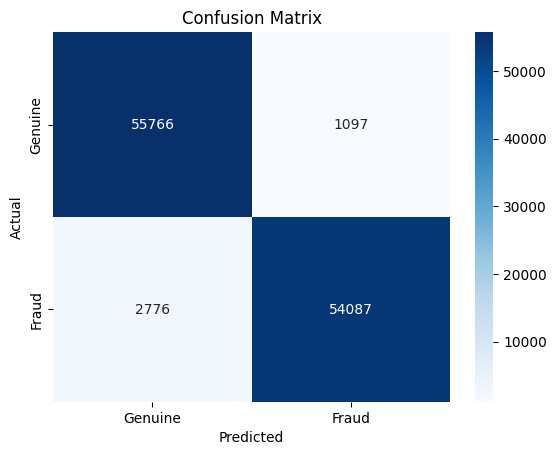

In [34]:
# Plot the confusion matrix for a better visualization
svm_cm = confusion_matrix(y_test.to_numpy(), svm_y_pred.to_numpy())
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 4. Support Vector Machine (RBF Kernel)

#### Training The Model

In [35]:
from cuml.svm import SVC


# Initialize the SVM model
svm_rbf_model = SVC(kernel='rbf', gamma='scale', C=1)



In [36]:
start_time = time.time()
svm_rbf_model.fit(X_train, y_train)
end_time = time.time()

training_time_svm_rbf = end_time - start_time
print(f"Training time SVM (RBF Kernel): {training_time_svm_rbf:.2f} seconds")

Training time SVM (RBF Kernel): 3.63 seconds


#### Making Predictions

In [37]:
# Predict on the test set
# svm_rbf_y_pred = svm_model.predict(X_test)
# svm_rbf_y_pred_prob = svm_rbf_model.predict_proba(X_test.to_pandas())[1]  # Probabilities for ROC-AUC calculation

# Predict on the test set
svm_rbf_y_pred = svm_rbf_model.predict(X_test)

# Decision scores for ROC-AUC
svm_rbf_y_score = svm_rbf_model.decision_function(X_test)

#### Evaluate the Model

#####  a.  Accuracy, Precision, Recall, and F1-Score


In [38]:
# Print evaluation metrics
svm_rbf_accuracy = accuracy_score(y_test, svm_rbf_y_pred)
svm_rbf_precision = precision_score(y_test.to_numpy(), svm_rbf_y_pred.to_numpy())
svm_rbf_recall = recall_score(y_test.to_numpy(), svm_rbf_y_pred.to_numpy())
svm_rbf_f1 = f1_score(y_test.to_numpy(), svm_rbf_y_pred.to_numpy())

print(f'Accuracy: {svm_rbf_accuracy:.4f}')
print(f'Precision: {svm_rbf_precision:.4f}')
print(f'Recall: {svm_rbf_recall:.4f}')
print(f'F1 Score: {svm_rbf_f1:.4f}')

Accuracy: 0.9971
Precision: 0.9963
Recall: 0.9979
F1 Score: 0.9971


##### b. ROC-AUC Score

In [39]:
svm_rbf_roc_auc = roc_auc_score(y_test, svm_rbf_y_score)
print(f'ROC-AUC Score: {svm_rbf_roc_auc:.4f}')

ROC-AUC Score: 0.9998


##### c. Classification Report

In [40]:
print("Classification Report:\n", classification_report(y_test.to_numpy(), svm_rbf_y_pred.to_numpy()))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



##### d. Confusion Matrix

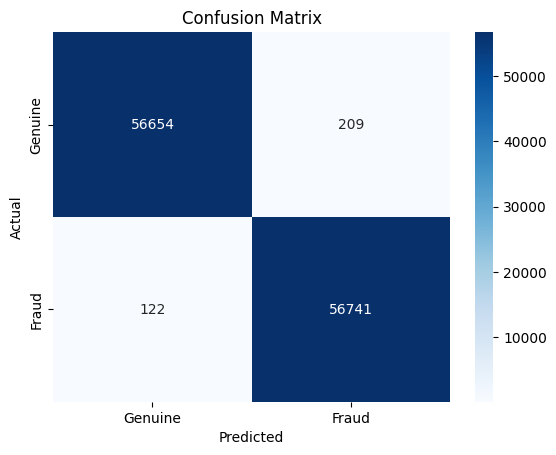

In [41]:
# Plot the confusion matrix for a better visualization
svm_rbf_cm = confusion_matrix(y_test.to_numpy(), svm_rbf_y_pred.to_numpy())
sns.heatmap(svm_rbf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Comparision

### Table of Metrices

In [42]:
comparision_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM (Linear Kernel)', 'SVM (RBF)'],
    'Accuracy': [lr_accuracy, rf_accuracy, svm_accuracy, svm_rbf_accuracy],
    'Precision': [lr_precision, rf_precision, svm_precision, svm_rbf_precision],
    'Recall': [lr_recall, rf_recall, svm_recall, svm_rbf_recall],
    'F1-Score': [lr_f1, rf_f1, svm_f1, svm_rbf_f1],
    'ROC AUC': [lr_roc_auc, rf_roc_auc, svm_roc_auc, svm_rbf_roc_auc]
}

In [43]:
# Convert dictionary into a pandas DataFrame
df = cudf.DataFrame(comparision_data)

In [44]:
df.set_index('Model', inplace=True)
df

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression,0.964995,0.977171,0.952236,0.964542,0.993525
Random Forest,0.999851,0.999701,1.000000,0.999851,1.000000
SVM (Linear Kernel),0.965944,0.980121,0.951181,0.965434,0.993086
SVM (RBF),0.997089,0.996330,0.997854,0.997092,0.999794


### ROC Curve

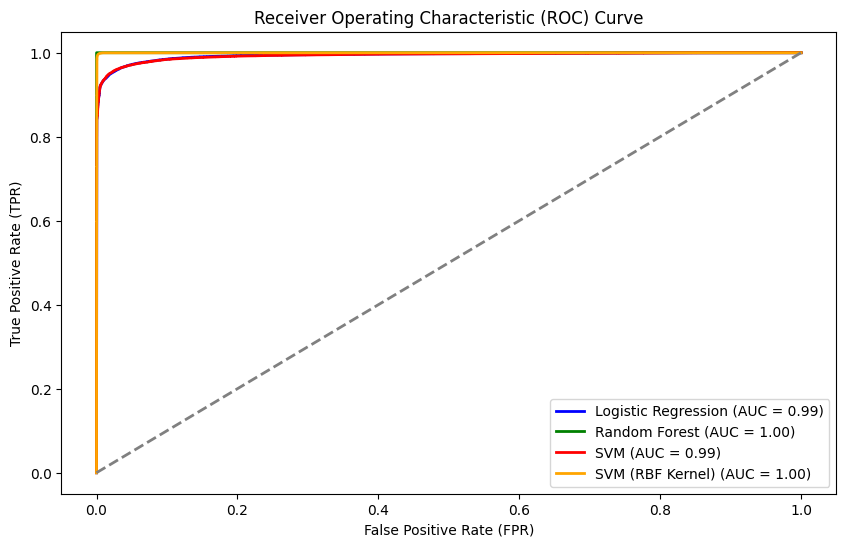

In [45]:
# Compute ROC curve and AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test.to_numpy(), lr_y_pred_prob.to_numpy())
fpr_rf, tpr_rf, _ = roc_curve(y_test.to_numpy(), rf_y_pred_prob.to_numpy())
fpr_svm, tpr_svm, _ = roc_curve(y_test.to_numpy(), svm_y_score.to_numpy())
fpr_svm_rbf, tpr_svm_rbf, _ = roc_curve(y_test.to_numpy(), svm_rbf_y_score.to_numpy())

roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_svm = auc(fpr_svm, tpr_svm)
roc_auc_svm_rbf = auc(fpr_svm_rbf, tpr_svm_rbf)


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_svm, tpr_svm, color='red', lw=2, label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot(fpr_svm_rbf, tpr_svm_rbf, color='orange', lw=2, label=f'SVM (RBF Kernel) (AUC = {roc_auc_svm_rbf:.2f})')

# Plot a diagonal line (chance line)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

# Labels and title
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')

# Show the plot
plt.show()

### Confusion Matrices

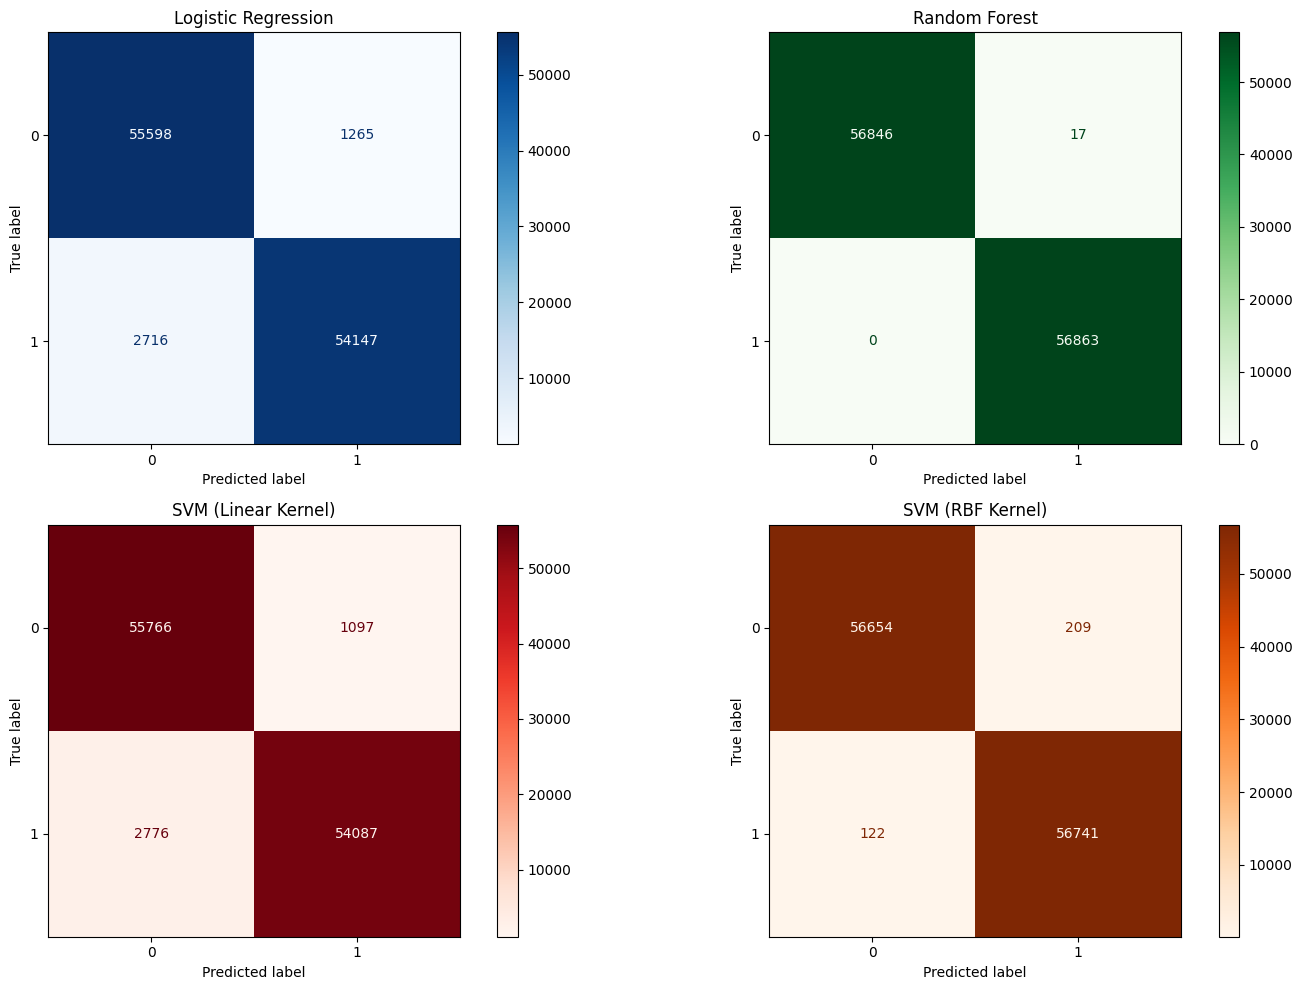

In [46]:
# Create 2x2 grid for subplots (leave the last one empty)
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Plot the confusion matrices
ConfusionMatrixDisplay(lr_cm).plot(ax=axs[0, 0], cmap='Blues')
axs[0, 0].set_title('Logistic Regression')

ConfusionMatrixDisplay(rf_cm).plot(ax=axs[0, 1], cmap='Greens')
axs[0, 1].set_title('Random Forest')

ConfusionMatrixDisplay(svm_cm).plot(ax=axs[1, 0], cmap='Reds')
axs[1, 0].set_title('SVM (Linear Kernel)')

ConfusionMatrixDisplay(svm_rbf_cm).plot(ax=axs[1, 1], cmap='Oranges')
axs[1, 1].set_title('SVM (RBF Kernel)')


# Adjust layout for better spacing
plt.tight_layout()
plt.show()

### Training Time

In [47]:
training_time = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM (Linear Kernel)', 'SVM (RBF)'],
    'Training Time': [training_time_lr, training_time_rf, training_time_svm, training_time_svm_rbf],
}

df = cudf.DataFrame(training_time)
df


,Model,Training Time
0,Logistic Regression,6.075090
1,Random Forest,4.375582
2,SVM (Linear Kernel),17.298541
3,SVM (RBF),3.629081


## Serializing Models

In [48]:
# Save models
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(svm_rbf_model, 'svm_rbf_model.pkl')

print("Models saved successfully!")

Models saved successfully!


## Extended Analysis: Dataset Scaling + GPU Utilization
This section extends the original benchmark with:
- Training-time measurement across increasing dataset sizes (10k to full)
- GPU memory utilization tracking during training


In [49]:
!pip install pynvml -q
import pynvml
pynvml.nvmlInit()
gpu_handle = pynvml.nvmlDeviceGetHandleByIndex(0)

def get_gpu_memory_mb():
    mem = pynvml.nvmlDeviceGetMemoryInfo(gpu_handle)
    return mem.used / (1024**2)

In [50]:
import pandas as pd
import gc

# Reload the raw (unscaled) dataset for a fair, leakage-free scaling experiment
dataset_pd = pd.read_csv('creditcard_2023.csv')

sizes = [10_000, 50_000, 100_000, 300_000, len(dataset_pd)]
scaling_results = []

from cuml.linear_model import LogisticRegression as LR_s
from cuml.ensemble import RandomForestClassifier as RF_s
from cuml.svm import SVC as SVM_s

for size in sizes:
    sample_pd = dataset_pd.sample(n=size, random_state=42).reset_index(drop=True)
    sample_gdf = cudf.from_pandas(sample_pd)

    Xs = sample_gdf.drop(columns=['id', 'Class']).astype('float32')
    ys = sample_gdf['Class'].astype('int32')

    t0 = time.time()
    Xs_train, Xs_test, ys_train, ys_test = train_test_split(
        Xs, ys, test_size=0.2, random_state=42, stratify=ys
    )
    Xs_train = Xs_train.reset_index(drop=True)
    Xs_test = Xs_test.reset_index(drop=True)
    ys_train = ys_train.reset_index(drop=True)
    ys_test = ys_test.reset_index(drop=True)
    split_time = time.time() - t0

    scaler_s = StandardScaler()
    t0 = time.time()
    Xs_train['Amount'] = scaler_s.fit_transform(Xs_train[['Amount']])
    Xs_test['Amount'] = scaler_s.transform(Xs_test[['Amount']])
    scale_time = time.time() - t0

    # ---- Logistic Regression ----
    gc.collect()
    mem_before = get_gpu_memory_mb()
    lr_s = LR_s()
    t0 = time.time()
    lr_s.fit(Xs_train, ys_train)
    lr_s_time = time.time() - t0
    mem_lr_delta = get_gpu_memory_mb() - mem_before
    del lr_s
    gc.collect()

    # ---- Random Forest ----
    mem_before = get_gpu_memory_mb()
    rf_s = RF_s(n_estimators=100)
    t0 = time.time()
    rf_s.fit(Xs_train, ys_train)
    rf_s_time = time.time() - t0
    mem_rf_delta = get_gpu_memory_mb() - mem_before
    del rf_s
    gc.collect()

    # ---- SVM (Linear kernel) ----
    mem_before = get_gpu_memory_mb()
    svm_lin_s = SVM_s(kernel='linear')
    t0 = time.time()
    svm_lin_s.fit(Xs_train, ys_train)
    svm_lin_s_time = time.time() - t0
    mem_svm_lin_delta = get_gpu_memory_mb() - mem_before
    del svm_lin_s
    gc.collect()

    # ---- SVM (RBF kernel) ----
    mem_before = get_gpu_memory_mb()
    svm_rbf_s = SVM_s(kernel='rbf')
    t0 = time.time()
    svm_rbf_s.fit(Xs_train, ys_train)
    svm_rbf_s_time = time.time() - t0
    mem_svm_rbf_delta = get_gpu_memory_mb() - mem_before
    del svm_rbf_s
    gc.collect()

    scaling_results.append({
        'dataset_size': size,
        'split_time': split_time,
        'scale_time': scale_time,
        'preprocess_time_total': split_time + scale_time,
        'lr_train_time': lr_s_time,
        'rf_train_time': rf_s_time,
        'svm_linear_train_time': svm_lin_s_time,
        'svm_rbf_train_time': svm_rbf_s_time,
        'gpu_memory_delta_mb_lr': mem_lr_delta,
        'gpu_memory_delta_mb_rf': mem_rf_delta,
        'gpu_memory_delta_mb_svm_linear': mem_svm_lin_delta,
        'gpu_memory_delta_mb_svm_rbf': mem_svm_rbf_delta,
    })

    print(f"[Size={size:>7}] LR={lr_s_time:.3f}s (memΔ={mem_lr_delta:+.0f}MB) | "
          f"RF={rf_s_time:.3f}s (memΔ={mem_rf_delta:+.0f}MB) | "
          f"SVM-Lin={svm_lin_s_time:.3f}s (memΔ={mem_svm_lin_delta:+.0f}MB) | "
          f"SVM-RBF={svm_rbf_s_time:.3f}s (memΔ={mem_svm_rbf_delta:+.0f}MB)")

scaling_df = pd.DataFrame(scaling_results)
scaling_df.to_csv('gpu_scaling_results.csv', index=False)
print("\nSaved results to gpu_scaling_results.csv")
scaling_df

[Size=  10000] LR=0.046s (memΔ=+0MB) | RF=0.991s (memΔ=+0MB) | SVM-Lin=0.194s (memΔ=+0MB) | SVM-RBF=0.031s (memΔ=+0MB)
[Size=  50000] LR=0.028s (memΔ=+0MB) | RF=1.277s (memΔ=+4MB) | SVM-Lin=0.476s (memΔ=+0MB) | SVM-RBF=0.097s (memΔ=+2MB)
[Size= 100000] LR=0.038s (memΔ=+0MB) | RF=1.550s (memΔ=+0MB) | SVM-Lin=1.295s (memΔ=+0MB) | SVM-RBF=0.235s (memΔ=+0MB)
[Size= 300000] LR=0.069s (memΔ=+0MB) | RF=2.710s (memΔ=+8MB) | SVM-Lin=5.626s (memΔ=+6MB) | SVM-RBF=1.255s (memΔ=+2MB)
[2026-10-06 07:40:14.166] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[Size= 568630] LR=0.202s (memΔ=+0MB) | RF=4.375s (memΔ=+6MB) | SVM-Lin=16.711s (memΔ=+6MB) | SVM-RBF=3.784s (memΔ=+0MB)

Saved results to gpu_scaling_results.csv


,dataset_size,split_time,scale_time,preprocess_time_total,lr_train_time,rf_train_time,svm_linear_train_time,svm_rbf_train_time,gpu_memory_delta_mb_lr,gpu_memory_delta_mb_rf,gpu_memory_delta_mb_svm_linear,gpu_memory_delta_mb_svm_rbf
0,10000,0.081437,12.404482,12.485919,0.045664,0.991402,0.193965,0.030620,0.0,0.0,0.0,0.0
1,50000,0.032361,0.014574,0.046936,0.027680,1.277468,0.476368,0.097208,0.0,4.0,0.0,2.0
2,100000,0.050090,0.016250,0.066340,0.038389,1.550102,1.295347,0.234862,0.0,0.0,0.0,0.0
3,300000,0.237522,0.021478,0.259001,0.069164,2.709825,5.625759,1.254611,0.0,8.0,6.0,2.0
4,568630,0.219071,0.019968,0.239039,0.202238,4.374738,16.710531,3.784143,0.0,6.0,6.0,0.0


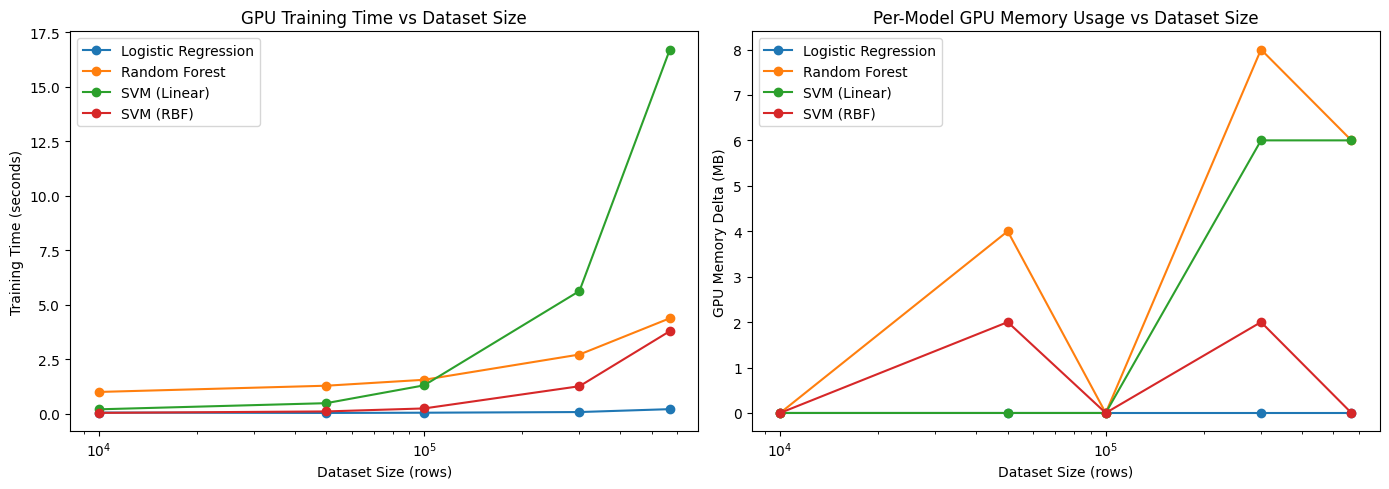

Done. Combine this with cpu_scaling_results.csv for the final crossover analysis.


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(scaling_df['dataset_size'], scaling_df['lr_train_time'], marker='o', label='Logistic Regression')
axes[0].plot(scaling_df['dataset_size'], scaling_df['rf_train_time'], marker='o', label='Random Forest')
axes[0].plot(scaling_df['dataset_size'], scaling_df['svm_linear_train_time'], marker='o', label='SVM (Linear)')
axes[0].plot(scaling_df['dataset_size'], scaling_df['svm_rbf_train_time'], marker='o', label='SVM (RBF)')
axes[0].set_xlabel('Dataset Size (rows)')
axes[0].set_ylabel('Training Time (seconds)')
axes[0].set_title('GPU Training Time vs Dataset Size')
axes[0].set_xscale('log')
axes[0].legend()

axes[1].plot(scaling_df['dataset_size'], scaling_df['gpu_memory_delta_mb_lr'], marker='o', label='Logistic Regression')
axes[1].plot(scaling_df['dataset_size'], scaling_df['gpu_memory_delta_mb_rf'], marker='o', label='Random Forest')
axes[1].plot(scaling_df['dataset_size'], scaling_df['gpu_memory_delta_mb_svm_linear'], marker='o', label='SVM (Linear)')
axes[1].plot(scaling_df['dataset_size'], scaling_df['gpu_memory_delta_mb_svm_rbf'], marker='o', label='SVM (RBF)')
axes[1].set_xlabel('Dataset Size (rows)')
axes[1].set_ylabel('GPU Memory Delta (MB)')
axes[1].set_title('Per-Model GPU Memory Usage vs Dataset Size')
axes[1].set_xscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig('gpu_scaling_plot.png', dpi=150)
plt.show()

print("Done. Combine this with cpu_scaling_results.csv for the final crossover analysis.")